# Computational Social Science Project #3 

**Enter your Name:** Vy Thai

*Semester:* Fall 2025

## 1. Introduction

### Load data 

In [36]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.2 MB/s eta 0:00:00


In [585]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, make_scorer, accuracy_score, recall_score, precision_score, f1_score
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')
import xgboost as xgb
import plotly.express as px

# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure to import other libraries that will be necessary for training models!

In [586]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [587]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Results,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pass_flag,fail_flag,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
0,269961,2013-01-31,SEVEN STAR,SEVEN STAR,30790,Grocery Store,Risk 3 (Low),3352 N BROADWAY,CHICAGO,IL,60657.0,Canvass,Pass,41.943359,-87.644999,"(41.943359344775146, -87.64499875300952)",Other,0,0,2,1,0,0,0,0,0,2.0,1,30790-20110416,2081412.0,63759.0,VIRGINIA DELA ROSA,SEVEN STAR,3352 N BROADWAY 1,CHICAGO,IL,60657.0,44.0,33.0,44-33,19.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,30790.0,RENEW,2011-04-16,2013-04-15,AAI,41.943359,-87.644999,2002-02-16,2015-04-15,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
1,507211,2011-10-18,PANERA BREAD,PANERA BREAD,1475890,Restaurant,Risk 1 (High),6059 N LINCOLN AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.991919,-87.709631,"(41.99191947239194, -87.70963133440333)",Restaurant,0,0,3,1,0,0,0,0,0,2.0,1,1475890-20110416,2081695.0,207283.0,"PANERA, LLC",PANERA BREAD,6059 N LINCOLN AVE C,CHICAGO,IL,60659.0,50.0,23.0,50-23,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1475890.0,RENEW,2011-04-16,2013-04-15,AAI,41.991919,-87.709631,2004-05-05,2019-04-15,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
2,507212,2011-10-18,LITTLE QUIAPO RESTAURANT,LITTLE QUIAPO RESTAURANT,1740130,Restaurant,Risk 1 (High),6259 N MCCORMICK RD,CHICAGO,IL,60659.0,Canvass,Fail,41.995632,-87.712707,"(41.99563177556418, -87.71270678169132)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1740130-20110216,2070145.0,3107.0,ENELITA GARCIA,LITTLE QUIAPO RESTAURANT,6259 N MCCORMICK RD,CHICAGO,IL,60659.0,50.0,25.0,50-25,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1740130.0,RENEW,2011-02-16,2013-02-15,AAI,41.995632,-87.712707,2007-03-22,2017-02-15,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
3,507216,2011-10-19,SERGIO'S TAQUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA,1447363,Restaurant,Risk 1 (High),3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.982933,-87.710982,"(41.982933189164974, -87.71098225381141)",Restaurant,0,0,6,1,0,0,0,0,0,2.0,1,1447363-20110216,2071895.0,270993.0,SERGIO'S TAZUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA INC.,3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,39.0,48.0,39-48,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1447363.0,RENEW,2011-02-16,2013-02-15,AAI,41.982933,-87.710982,2003-12-31,2019-02-15,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
4,507219,2011-10-20,TARGET STORE # T-2079,TARGET,1679459,Restaurant,Risk 2 (Medium),2112 W PETERSON AVE,CHICAGO,IL,60659.0,Canvass,Fail,41.990729,-87.682979,"(41.99072921796059, -87.68297945359863)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1679459-20100216,2009972.0,15538.0,TARGET CORPORATION,TARGET STORE # T-2079,2112 W PETERSON AVE,CHICAGO,IL,60659.0,40.0,18.0,40-18,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1679459.0,RENEW,

In [588]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

In [589]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [590]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

In [591]:
# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)
counts_by_day.plot(title = "Inspections by Month and Year") 

<Axes: title={'center': 'Inspections by Month and Year'}, xlabel='Inspection_MonthYear'>

Let's visualize what the distribution of results looks like.

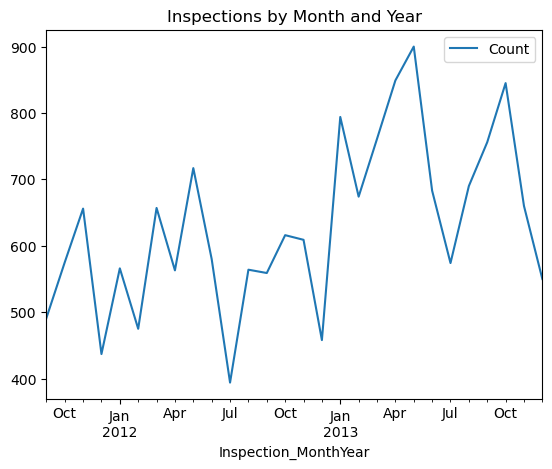

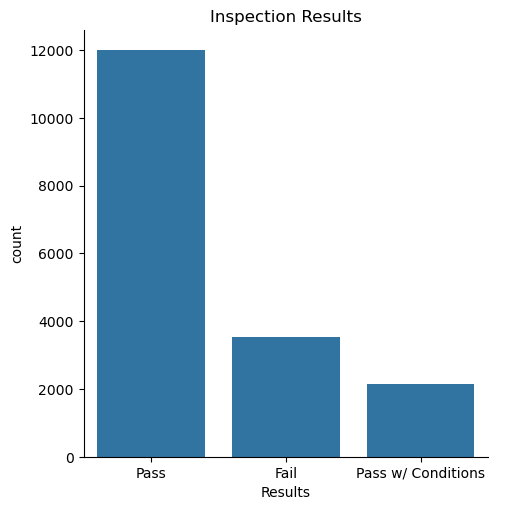

In [592]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

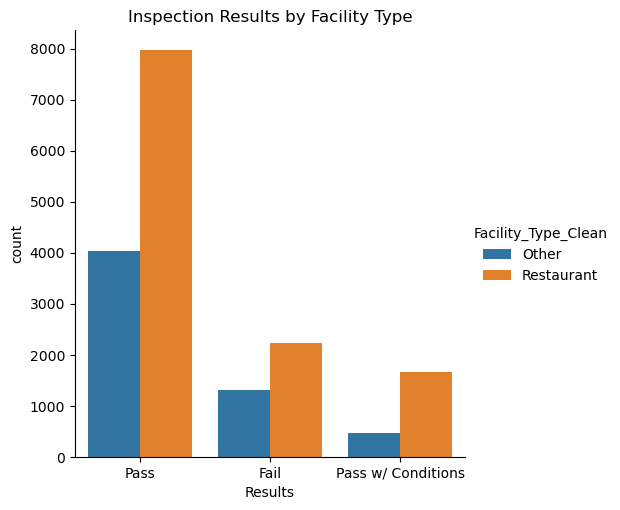

In [593]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

## 2. Data Preprocessing and Cleaning

In [594]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

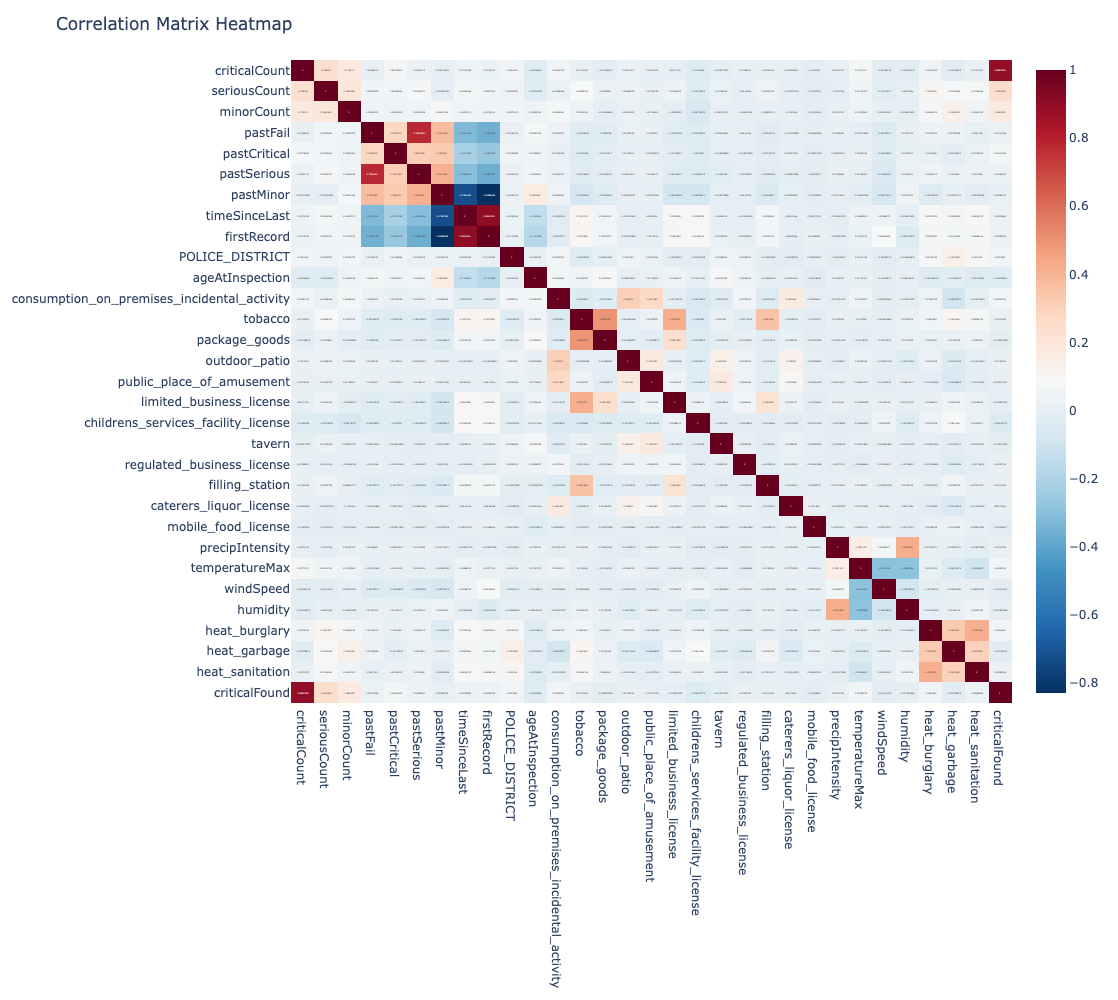

In [595]:
chicago_inspections_2011_to_2013_numeric = chicago_inspections_2011_to_2013.select_dtypes(include=['number'])
correlation_matrix = chicago_inspections_2011_to_2013_numeric.corr()

fig = px.imshow(correlation_matrix,
                text_auto=True,
                height=1000,
                color_continuous_scale='RdBu_r',
                aspect="auto") 

fig.update_layout(title_text='Correlation Matrix Heatmap')
fig.show()

In [648]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT' 
                                                    ])


# get dummies
X = pd.get_dummies(X)
X = pd.get_dummies(X, columns=['POLICE_DISTRICT']) # one-hot coding for police_district which is a categorical feature

In [649]:
X = X.drop(columns = ['criticalFound']) # drop highly correlated with criticalCount

In [650]:
# view feature datset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW,POLICE_DISTRICT_1.0,POLICE_DISTRICT_2.0,POLICE_DISTRICT_3.0,POLICE_DISTRICT_4.0,POLICE_DISTRICT_5.0,POLICE_DISTRICT_6.0,POLICE_DISTRICT_7.0,POLICE_DISTRICT_8.0,POLICE_DISTRICT_9.0,POLICE_DISTRICT_10.0,POLICE_DISTRICT_11.0,POLICE_DISTRICT_12.0,POLICE_DISTRICT_14.0,POLICE_DISTRICT_15.0,POLICE_DISTRICT_16.0,POLICE_DISTRICT_17.0,POLICE_DISTRICT_18.0,POLICE_DISTRICT_19.0,POLICE_DISTRICT_20.0,POLICE_DISTRICT_22.0,POLICE_DISTRICT_24.0,POLICE_DISTRICT_25.0,POLICE_DISTRICT_81.0
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,False,False,True,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

In [651]:
# train/validation splits
np.random.seed(10)

X_train, X_validate, y_train, y_validate = train_test_split(X, 
                                                    y, 
                                                    train_size = .80, 
                                                    test_size=0.20,
                                                    stratify=y)

### Model 1 - Logistic Regression

Logistic Regression is a great first choice because it gives us a solid baseline model to build intuition and compare the others against. Having straightforward coefficients make it easy to understand which factors, such as past violations, risk categories, or specific police districts most strongly influence failure predictions. However, a key limitation is the assumption of a linear relationship between features and outcomes, which may oversimplify the real-world interactions present in food safety compliance.

In [652]:
logit_reg = LogisticRegression() 

# hyperparameters searching
param_grid = {'penalty': ['l1', 'l2', 'elasticnet'],
             'C': np.arange(.1, 1, .1),
             'fit_intercept': [True, False],
             'solver': ['liblinear', 'saga']}

logit_grid = GridSearchCV(logit_reg, 
                          param_grid, 
                          cv=5)

# fit with best hyperparameters
logit_grid.fit(X_train, y_train)

best_logit_model = logit_grid.best_estimator_
best_index = np.argmax(logit_grid.cv_results_["mean_test_score"])
best_logit_pred = best_logit_model.predict(X_validate)

print(logit_grid.cv_results_["params"][best_index])
print('Validation Accuracy', accuracy_score(best_logit_pred, y_validate))

{'C': np.float64(0.1), 'fit_intercept': True, 'penalty': 'elasticnet', 'solver': 'liblinear'}
Validation Accuracy 0.9285014691478942


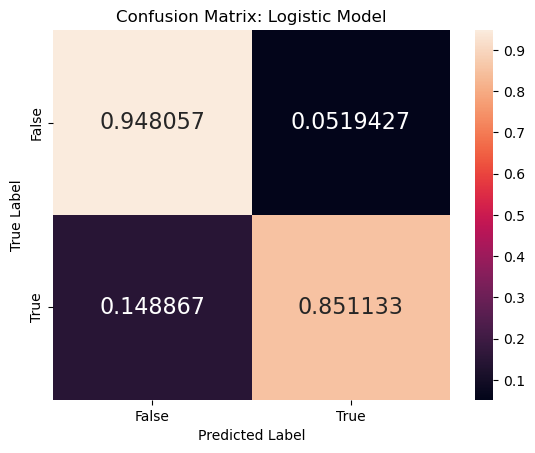

In [653]:
# confusion matrix
cf_matrix = confusion_matrix(y_validate, 
                             best_logit_pred, 
                             normalize = "true")

df_cm = pd.DataFrame(cf_matrix)
df_cm = df_cm.rename(index   = {0: "False", 1: "True"},
                     columns = {0: "False", 1: "True"})            

sns.heatmap(df_cm,                                                   
           annot=True,                            
           annot_kws={"size": 16},              
           fmt='g')                               
plt.title("Confusion Matrix: Logistic Model")                  
plt.xlabel("Predicted Label")                  
plt.ylabel("True Label")                             
plt.show()   

###  Model 2 - Random Forest

Random Forest utilizes bagging to create an ensemble of decision trees, making it robust for capturing complex, non-linear relationships without requiring extensive hyperparameter tuning. It handles interactions between features such as violation history, business type, and neighborhood conditions particularly well, and reduces overfitting by averaging multiple trees. A downside is its lower interpretability compared to logistic regression, and it may still miss subtle sequential patterns that boosting methods can capture.

In [654]:
rf_classifer = RandomForestClassifier(random_state=10)

# hyperparameter tuning
rf_param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [10, 20, None],             
    'min_samples_split': [2, 5, 10],       
    'min_samples_leaf': [1, 4, 7, 10]        
}

rf_grid = GridSearchCV(rf_classifer, 
                       rf_param_grid, 
                       cv=5)

# Fit with best hyperparameters
rf_grid.fit(X_train, y_train.ravel())

best_rf_model = rf_grid.best_estimator_
best_index = np.argmax(rf_grid.cv_results_["mean_test_score"])
best_rf_pred = best_rf_model.predict(X_validate)

print(rf_grid.cv_results_["params"][best_index])
print('Validation Accuracy', accuracy_score(best_rf_pred, y_validate))

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Validation Accuracy 0.9324191968658179


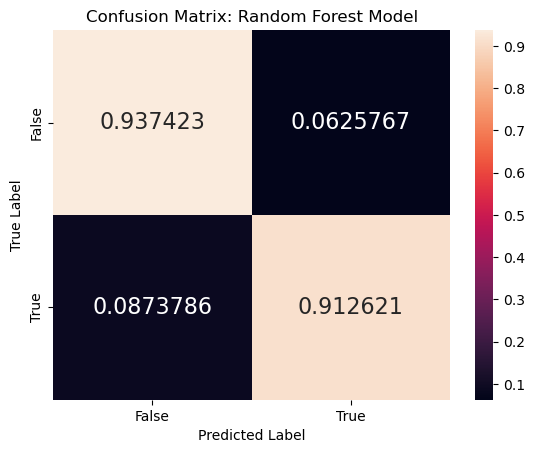

In [655]:
# confusion matrix
cf_matrix = confusion_matrix(y_validate, 
                             best_rf_pred, 
                             normalize = "true")

df_cm = pd.DataFrame(cf_matrix)
df_cm = df_cm.rename(index   = {0: "False", 1: "True"},
                     columns = {0: "False", 1: "True"})            

sns.heatmap(df_cm,                                                   
           annot=True,                            
           annot_kws={"size": 16},              
           fmt='g')                               
plt.title("Confusion Matrix: Random Forest Model")                  
plt.xlabel("Predicted Label")                  
plt.ylabel("True Label")                             
plt.show()   

### Model 3 - XGBoost

XGBoost is generally known for high performance on structured data and in prediction tasks. Using a gradient boosting framework, it sequentially corrects errors from previous trees, allowing it to model hierarchical relationships and subtle risk signals, such as the combined effect of a specific neighborhood and business type. However, it requires more careful tuning, is computationally more expensive, and has less transparency than simpler models, which can be a drawback in policy-sensitive contexts.

In [656]:
xgb_classifier = xgb.XGBClassifier(random_state=10)

# hyperparameter tuning
xgb_param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [3, 5, 6],             
    'min_child_weight': [1, 3, 5],       
    'learning_rate': [0.01, 0.1, 0.3], 
    'gamma': [0, 0.1, 0.2]        
}

xgb_grid = GridSearchCV(xgb_classifier, 
                       xgb_param_grid, 
                       cv=5)

# Fit with best hyperparameters
xgb_grid.fit(X_train, y_train.ravel())

best_xgb_model = xgb_grid.best_estimator_
best_index = np.argmax(xgb_grid.cv_results_["mean_test_score"])
best_xgb_pred = best_xgb_model.predict(X_validate)

print(xgb_grid.cv_results_["params"][best_index])
print('Validation Accuracy', accuracy_score(best_xgb_pred, y_validate))

{'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100}
Validation Accuracy 0.9340515834149526


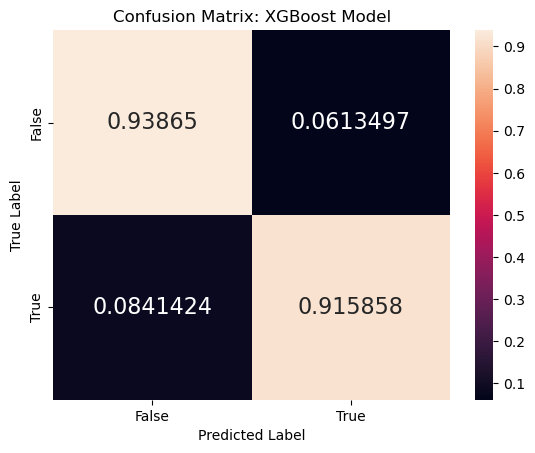

In [657]:
# confusion matrix
cf_matrix = confusion_matrix(y_validate, 
                             best_xgb_pred, 
                             normalize = "true")

df_cm = pd.DataFrame(cf_matrix)
df_cm = df_cm.rename(index   = {0: "False", 1: "True"},
                     columns = {0: "False", 1: "True"})            

sns.heatmap(df_cm,                                                   
           annot=True,                            
           annot_kws={"size": 16},              
           fmt='g')                               
plt.title("Confusion Matrix: XGBoost Model")                  
plt.xlabel("Predicted Label")                  
plt.ylabel("True Label")                             
plt.show()   

### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

In the context of predictive auditing for food safety inspections, recall should be the prioritized metric. Recall answers the question "Of all the items that were actually positive, how many did the model find?". In our case, it measures the proportion of actual failing establishments (label=True/1) that are correctly identified by the model. 

Comparing to Precision, which focuses on minimizing the False Positives, Recall focuses on minimizing the False Negatives, ie. to avoid mis-classifying dangerous establishments as non-dangerous. The costs of FNs are substantially more than that of FNs, since a missed violation could lead to serious foodborne illness outbreaks.

F1 is another helpful metric that balances both Recall and Precision, making it a good choice if there's little variance between the two, or if balancing both aspects is important (e.g. when over-auditing safe restaurants is a resource concern)

I will go with Random Forest since it has both the highest Recall and F1, among other benefits.

In [658]:
models = {
          'Logistic Regression': best_logit_model,
          'Random Forest': best_rf_model,
          'XGBoost': best_xgb_model,
          }

scoring = {
          'accuracy': make_scorer(accuracy_score),
          'recall': make_scorer(recall_score),
          'precision': make_scorer(precision_score),
          'f1': make_scorer(f1_score)
          }

for name, model in models.items():
    print(f"\n___________________\n{name}:")
    cv_results = cross_validate(model,        
                                X_validate,                     
                                y_validate.ravel(),            
                                cv=5,                
                                return_estimator=True, 
                                scoring=scoring)     
 
    for metric in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
        scores = cv_results[metric]
        print(f"{metric[5:]}: {scores.mean():.3f}")


___________________
Logistic Regression:
accuracy: 0.924
recall: 0.849
precision: 0.789
f1: 0.818

___________________
Random Forest:
accuracy: 0.926
recall: 0.877
precision: 0.782
f1: 0.826

___________________
XGBoost:
accuracy: 0.926
recall: 0.872
precision: 0.785
f1: 0.826


## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.


All three models somewhat identify similar important features, such as seriousCount, criticalCount, and Risk level. Logit and XGBoost did identify specific police districts (like 18, 19, and 24) as top features, while RF did not. Since RF uses bagging, which creates mmany trees on random data subsets, the importance of sparse categorical features like POLICE_DISTRICT_19 probably got averaged out. Features like heat_garbage, ageAtInspection, etc are more universally predictive across all the random samples because they apply to businesses everywhere, not just in one district.

For this model, RF seems like a good choice due to its capture of universally predictive features, which makes it easily applicable to other policy applications and geographic locations.

Additional features that could improve prediction include ownership history (repeat violators under different business names), complaint records from 311 calls, and real-time data such as recent employee turnover or changes in management.

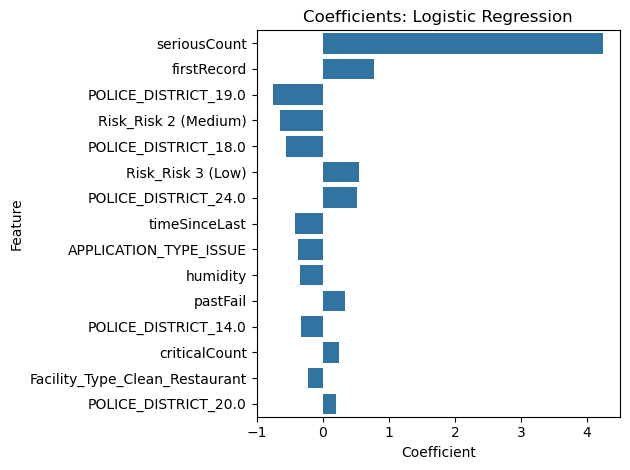

In [659]:
# Logistic
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_logit_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

ax = sns.barplot(x="Coefficient",                        
                 y="Feature",    
                 data=logit_data.nlargest(15, 'Absolute_Coefficient')) # display top 10                   

ax.set_title("Coefficients: Logistic Regression")                           
plt.tight_layout()
plt.show()                                              

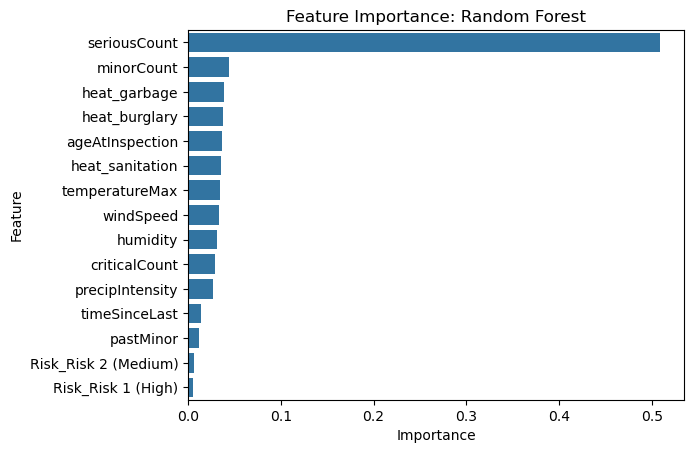

In [660]:
# Random Forest
rf.fit(X, y.ravel())

feat_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# plot 
sns.barplot(x = "Importance", 
            y = "Feature", 
            data = feat_importances.nlargest(15, 'Importance')) # identify the 10 most important features
plt.title("Feature Importance: Random Forest")                  
plt.show()

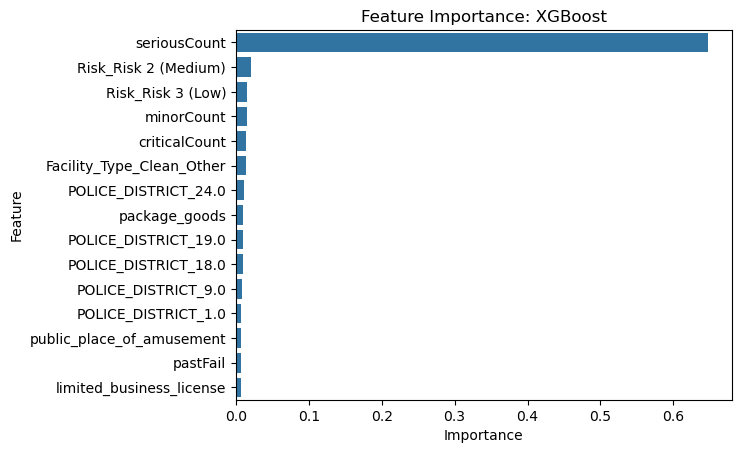

In [661]:
# XGBoost
xgb_classifier.fit(X, y.ravel())

feat_importances = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(xgb_classifier.feature_importances_))], axis = 1)
feat_importances.columns = ["Feature", "Importance"]

# plot 
sns.barplot(x = "Importance", 
            y = "Feature", 
            data = feat_importances.nlargest(15, 'Importance')) # identify the 10 most important features
plt.title("Feature Importance: XGBoost")                  
plt.show()

### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

In [662]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
# -----------
# using Random Forest model

In [663]:
#
# 2. Order your audits by their probability of detecting a "Fail" score
# -----------
probabilities = best_rf_model.predict_proba(X_validate)[:, 1]

results_df = pd.DataFrame({
    'Inspection_ID': X_validate.index,
    'Actual_Fail': y_validate.ravel(),
    'Predicted_Fail': best_rf_pred,
    'Predicted_Fail_Probability': probabilities
})
prioritized_audits = results_df.sort_values('Predicted_Fail_Probability', ascending=False)
prioritized_audits

,Inspection_ID,Actual_Fail,Predicted_Fail,Predicted_Fail_Probability
2650,"(1228047, MARATHON)",1,1,0.921696
67,"(1227463, PEACHES)",1,1,0.915994
1934,"(671107, RUNWAY SUBMARINE)",1,1,0.905208
1045,"(547712, SHOP RITE FOOD MART, INC)",1,1,0.897054
2333,"(1360400, SOMBRERO)",1,1,0.889821
...,...,...,...,...
181,"(1134621, SUBWAY)",0,0,0.000000
2506,"(1151126, POTBELLY SANDWICH WORKS LLC)",0,0,0.000000
614,"(1235432, STARBUCKS)",0,0,0.000000
1988,"(1198880, ALLENDE RESTAURANT #2)",0,0,0.000000


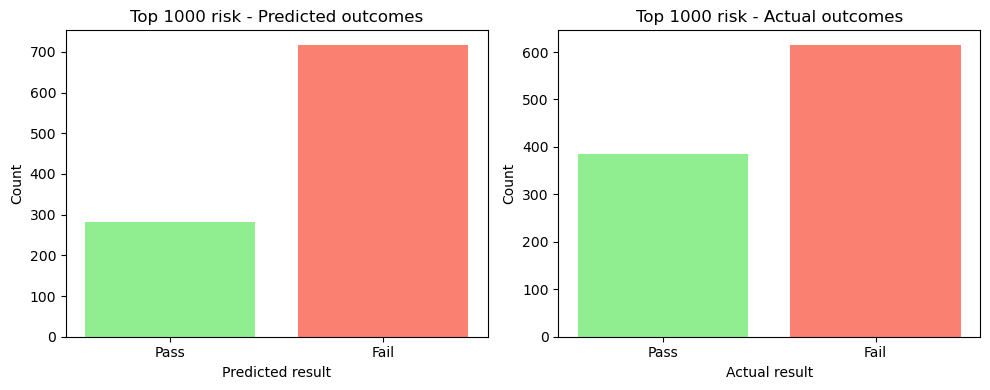

In [664]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
# -----------
top_1000 = prioritized_audits.head(1000)

top_1000_predicted_pass = (top_1000['Predicted_Fail'] == 0).sum()
top_1000_predicted_fail = (top_1000['Predicted_Fail'] == 1).sum()

top_1000_actual_pass = (top_1000['Actual_Fail'] == 0).sum()
top_1000_actual_fail = (top_1000['Actual_Fail'] == 1).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(['Pass', 'Fail'], [top_1000_predicted_pass, top_1000_predicted_fail], color=['lightgreen', 'salmon'])
ax1.set_title('Top 1000 risk - Predicted outcomes')
ax1.set_xlabel('Predicted result')
ax1.set_ylabel('Count')

ax2.bar(['Pass', 'Fail'], [top_1000_actual_pass, top_1000_actual_fail], color=['lightgreen', 'salmon'])
ax2.set_title('Top 1000 risk - Actual outcomes')
ax2.set_xlabel('Actual result')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

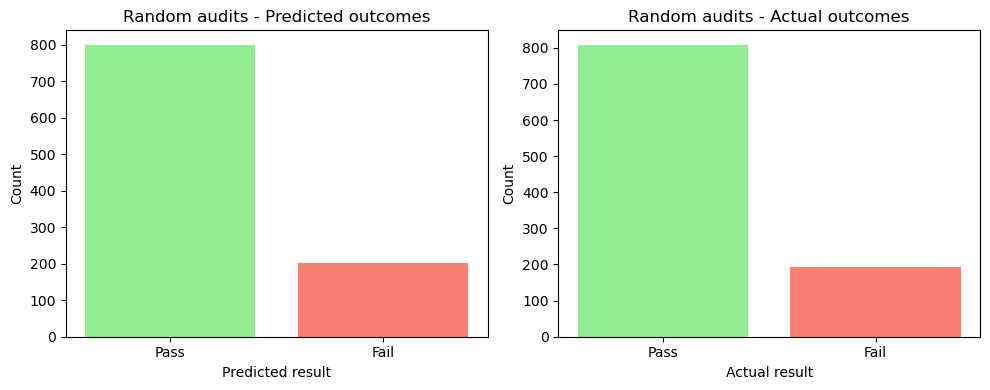

In [665]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random
# -----------
full_probabilities = best_rf_model.predict_proba(X)[:, 1]
best_rf_pred_full = best_rf_model.predict(X)

full_results_df = pd.DataFrame({
    'Inspection_ID': X.index,
    'Actual_Fail': y.ravel(),
    'Predicted_Fail': best_rf_pred_full,
    'Predicted_Fail_Probability': full_probabilities
})

random_audits = full_results_df.sample(n=1000, random_state=30)

random_audits_predicted_pass = (random_audits['Predicted_Fail'] == 0).sum()
random_audits_predicted_fail = (random_audits['Predicted_Fail'] == 1).sum()

random_audits_actual_pass = (random_audits['Actual_Fail'] == 0).sum()
random_audits_actual_fail = (random_audits['Actual_Fail'] == 1).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(['Pass', 'Fail'], [random_audits_predicted_pass, random_audits_predicted_fail], color=['lightgreen', 'salmon'])
ax1.set_title('Random audits - Predicted outcomes')
ax1.set_xlabel('Predicted result')
ax1.set_ylabel('Count')

ax2.bar(['Pass', 'Fail'], [random_audits_actual_pass, random_audits_actual_fail], color=['lightgreen', 'salmon'])
ax2.set_title('Random audits - Actual outcomes')
ax2.set_xlabel('Actual result')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

Auditing based on probability of Fail risk is better than random audits. The model is slightly over-predicting risk, however this is in favor of prioritizing the high Recall rate, which is rather conservative but appropriate for this kind of policy recommendation. Future iterations could optimize the probability threshold to better balance precision and recall metrics

### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [666]:
old_columns = set(chicago_inspections_2011_to_2013.columns)
new_columns = set(chicago_inspections_2014.columns)
columns_only_in_2014 = new_columns - old_columns
columns_only_in_old = old_columns - new_columns
print('columns_only_in_2014:', columns_only_in_2014, '\n')
print('columns_only_in_old', columns_only_in_old)

columns_only_in_2014: {'BUSINESS_ACTIVITY', 'Latitude', 'ACCOUNT_NUMBER', 'STATE', 'LONGITUDE', 'LEGAL_NAME', 'LICENSE_TERM_EXPIRATION_DATE', 'maxDate', 'BUSINESS_ACTIVITY_ID', 'DBA_Name', 'Address', 'Inspection_ID', 'WARD', 'CITY', 'ID', 'Inspection_Date', 'State', 'City', 'PRECINCT', 'Location', 'ZIP_CODE', 'LICENSE_CODE', 'LICENSE_TERM_START_DATE', 'minDate', 'AKA_Name', 'DOING_BUSINESS_AS_NAME', 'ADDRESS', 'Zip', 'Longitude', 'LICENSE_ID', 'LICENSE_NUMBER', 'LATITUDE', 'License', 'LICENSE_STATUS'} 

columns_only_in_old set()


In [674]:
# data processing
# -----------
# process features

columns_to_drop_2014 = list(columns_only_in_2014) + ['Inspection_Date',
                                                     'minDate', 
                                                     'maxDate',
                                                     # 'Inspection_MonthYear',
                                                     'Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT',
                                                     'criticalFound' 
                                                    ]
X_test2014 = chicago_inspections_2014.drop(columns=columns_to_drop_2014)

X_test2014 = pd.get_dummies(X_test2014)
X_test2014 = pd.get_dummies(X_test2014, columns=['POLICE_DISTRICT'])

# process target 
y_test2014 = chicago_inspections_2014['Results']

y_test2014 = y_test2014.replace({'Pass w/ Conditions': 'Pass'})
y_test2014 = lb_style.transform(y_test2014) 
y_test2014 = np.where(y_test2014 == 1, 0, 1)

# add missing columns with 0s
missing_cols = set(X_train.columns) - set(X_test2014.columns)
for col in missing_cols:
    X_test2014[col] = 0  
X_test2014 = X_test2014[X_train.columns] # enforce same order

print('Training features:', X.shape)
print('Test 2014 features:', X_test2014.shape)

Training features: (15311, 62)
Test 2014 features: (4623, 62)



___________________
2014 performance:
Accuracy:  0.909
Recall:    0.855
Precision: 0.724
F1:  0.784

___________________
2011-2013 performance:
Accuracy:  0.932
Recall:    0.913
Precision: 0.787
F1:  0.845


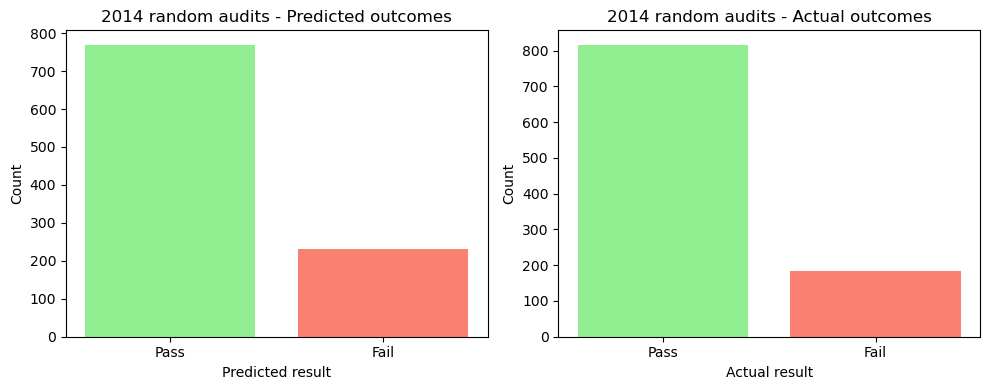

In [675]:
# predict and compare 
# -----------
test_predictions = best_rf_model.predict(X_test2014)
test_probabilities = best_rf_model.predict_proba(X_test2014)[:, 1]

print(f"\n___________________\n2014 performance:")
print(f"Accuracy:  {accuracy_score(y_test2014, test_predictions):.3f}")
print(f"Recall:    {recall_score(y_test2014, test_predictions):.3f}")
print(f"Precision: {precision_score(y_test2014, test_predictions):.3f}")
print(f"F1:  {f1_score(y_test2014, test_predictions):.3f}")

print(f"\n___________________\n2011-2013 performance:")
print(f"Accuracy:  {accuracy_score(y_validate, best_rf_pred):.3f}")
print(f"Recall:    {recall_score(y_validate, best_rf_pred):.3f}")
print(f"Precision: {precision_score(y_validate, best_rf_pred):.3f}")
print(f"F1:  {f1_score(y_validate, best_rf_pred):.3f}")


# random audits distribution
df_2014 = pd.DataFrame({
    'Inspection_ID': X_test2014.index,
    'Actual_Fail': y_test2014.ravel(),
    'Predicted_Fail': test_predictions,
    'Predicted_Fail_Probability': test_probabilities
})

random_audit_2014 = df_2014.sample(n=1000, random_state=30)

random_audits_predicted_pass_2014 = (random_audit_2014['Predicted_Fail'] == 0).sum()
random_audits_predicted_fail_2014 = (random_audit_2014['Predicted_Fail'] == 1).sum()

random_audits_actual_pass_2014 = (random_audit_2014['Actual_Fail'] == 0).sum()
random_audits_actual_fail_2014 = (random_audit_2014['Actual_Fail'] == 1).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(['Pass', 'Fail'], [random_audits_predicted_pass_2014, random_audits_predicted_fail_2014], color=['lightgreen', 'salmon'])
ax1.set_title('2014 random audits - Predicted outcomes')
ax1.set_xlabel('Predicted result')
ax1.set_ylabel('Count')

ax2.bar(['Pass', 'Fail'], [random_audits_actual_pass_2014, random_audits_actual_fail_2014], color=['lightgreen', 'salmon'])
ax2.set_title('2014 random audits - Actual outcomes')
ax2.set_xlabel('Actual result')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [557]:
# evaluate
# -----------

The model shows decent generalization to new data, with only a modest performance drop (and expected for future data) on the 2014 test set compared to the 2011-2013 training period. The distribution of Pass/Fail for random audits also look consistent with the previous years'data.

## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?

Relying solely on accuracy can be misleading, especially when outcomes are imbalanced or the costs of different errors are unequal. In food inspection prediction, a high accuracy could mask a failure to catch actual violations if most restaurants pass. As for other metrics, recall helps identify as many true failures as possible, and precision helps avoid wasting resources on false alarms. In public policy, the consequences of missing a violation (eg. public health risks) often outweigh the cost of an unnecessary inspection, making nuanced performance evaluation essential.

2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

While some predictive features, like a business's history of previous failures or critical citations, are inherently difficult to manipulate, businesses can still game the system by targeting more malleable inputs. For example, changing reported Facility_Type or license categories to appear lower risk. This kind of strategic adaptation creates a feedback loop where the model's effectiveness decreases as it is trained on data that no longer reflects real risk.

Strategies should be both adaptive and robust:

* Regularly updating the model with the latest inspection data helps it learn and adjust to the changing nature of these businesses, ensuring predictions remain relevant

* Prioritizing hard to game features, such as aggregated neighborhood-level data (heat_sanitation) or using the history of violations rather than just the most recent count

* Randomness: auditing a small random subset of establishments outside the model's high-risk list can help detect new forms of risk the model may have missed and adds another layer of uncertainty for businesses